In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("housepricedata.csv")
df

,LotArea,OverallQual,OverallCond,TotalBsmtSF,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageArea,AboveMedianPrice
0,8450,7,5,856,2,1,3,8,0,548,1
1,9600,6,8,1262,2,0,3,6,1,460,1
2,11250,7,5,920,2,1,3,6,1,608,1
3,9550,7,5,756,1,0,3,7,1,642,0
4,14260,8,5,1145,2,1,4,9,1,836,1
...,...,...,...,...,...,...,...,...,...,...,...
1455,7917,6,5,953,2,1,3,7,1,460,1
1456,13175,6,6,1542,2,0,3,7,2,500,1
1457,9042,7,9,1152,2,0,4,9,2,252,1
1458,9717,5,6,1078,1,0,2,5,0,240,0


In [3]:
dataset = df.values
dataset

array([[ 8450,     7,     5, ...,     0,   548,     1],
       [ 9600,     6,     8, ...,     1,   460,     1],
       [11250,     7,     5, ...,     1,   608,     1],
       ...,
       [ 9042,     7,     9, ...,     2,   252,     1],
       [ 9717,     5,     6, ...,     0,   240,     0],
       [ 9937,     5,     6, ...,     0,   276,     0]], shape=(1460, 11))

In [4]:
x = dataset[:,0:10]  # first 10 collumns only and all rows
y = dataset[:,10] # last column

In [5]:
from sklearn import preprocessing

In [6]:
min_max_scaler = preprocessing.MinMaxScaler()
X_scale = min_max_scaler.fit_transform(x)
X_scale

array([[0.0334198 , 0.66666667, 0.5       , ..., 0.5       , 0.        ,
        0.3864598 ],
       [0.03879502, 0.55555556, 0.875     , ..., 0.33333333, 0.33333333,
        0.32440056],
       [0.04650728, 0.66666667, 0.5       , ..., 0.33333333, 0.33333333,
        0.42877292],
       ...,
       [0.03618687, 0.66666667, 1.        , ..., 0.58333333, 0.66666667,
        0.17771509],
       [0.03934189, 0.44444444, 0.625     , ..., 0.25      , 0.        ,
        0.16925247],
       [0.04037019, 0.44444444, 0.625     , ..., 0.33333333, 0.        ,
        0.19464034]], shape=(1460, 10))

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_val_and_test, Y_train, Y_val_and_test = train_test_split(X_scale, y, test_size=0.3)
#30% will be validation and test  #70% will be trained

X_val, X_test, Y_val, Y_test = train_test_split(X_val_and_test, Y_val_and_test, test_size=0.5)
#    X_train (10 input features, 70% of full dataset)
#    X_val (10 input features, 15% of full dataset)
#    X_test (10 input features, 15% of full dataset)
#    Y_train (1 label, 70% of full dataset)
#    Y_val (1 label, 15% of full dataset)
#    Y_test (1 label, 15% of full dataset)

In [8]:
print(X_train.shape, X_val.shape, X_test.shape, Y_train.shape, Y_val.shape, Y_test.shape)
# train have 1022 data points and test/validation have 219
# X has 10 input features while Y has 1

(1022, 10) (219, 10) (219, 10) (1022,) (219,) (219,)


In [9]:
#look at image in folder. Our neural network architecture
#Hidden layer 1: 32 neurons, ReLU activation
#Hidden layer 2: 32 neurons, ReLU activation
#Output Layer: 1 neuron, Sigmoid activation

In [10]:
from keras.models import Sequential #we merely need to describe the layers above in sequence
from keras.layers import Dense

ModuleNotFoundError: No module named 'tensorflow'

In [34]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(10,)), #input shape is 10 since we have 10 input features
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid'),
])
#dense referse to a fully connected layer

In [35]:
model.compile(optimizer='sgd',  
              loss='binary_crossentropy',
              metrics=['accuracy']) #we want to track accuracy

In [36]:
hist = model.fit(X_train, Y_train, #fitting parameters to the data, we have to specify what data we are training on.
          batch_size=32, epochs=100, #specify size of our minibatch and how long we want to train it (epochs)
          validation_data=(X_val, Y_val)) #validation data which will tell us how we are doing at each point

Epoch 1/100
32/32 [==============================] - 1s 6ms/step - loss: 0.7050 - accuracy: 0.4971 - val_loss: 0.6956 - val_accuracy: 0.5571
Epoch 2/100
32/32 [==============================] - 0s 3ms/step - loss: 0.6990 - accuracy: 0.4980 - val_loss: 0.6904 - val_accuracy: 0.5571
Epoch 3/100
32/32 [==============================] - 0s 3ms/step - loss: 0.6939 - accuracy: 0.4961 - val_loss: 0.6860 - val_accuracy: 0.5616
Epoch 4/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6894 - accuracy: 0.5000 - val_loss: 0.6816 - val_accuracy: 0.5616
Epoch 5/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6846 - accuracy: 0.5049 - val_loss: 0.6772 - val_accuracy: 0.5616
Epoch 6/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6803 - accuracy: 0.5215 - val_loss: 0.6729 - val_accuracy: 0.5662
Epoch 7/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6756 - accuracy: 0.5205 - val_loss: 0.6689 - val_accuracy: 0.5982
Epoch 8/100
3

In [40]:
model.evaluate(X_test, Y_test)[1] # 1 returns loss at first element and accuracy as second element

7/7 [==============================] - 0s 1ms/step - loss: 0.2245 - accuracy: 0.9269


0.9269406199455261

In [41]:
import matplotlib.pyplot as plt

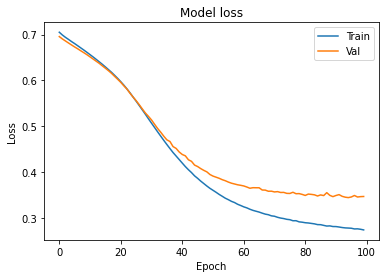

In [42]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

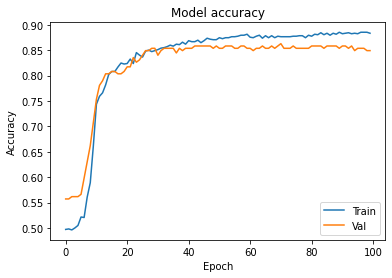

In [45]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

In [46]:
model_2 = Sequential([
    Dense(1000, activation='relu', input_shape=(10,)),
    Dense(1000, activation='relu'),
    Dense(1000, activation='relu'),
    Dense(1000, activation='relu'),
    Dense(1, activation='sigmoid'),
])

model_2.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
              
hist_2 = model_2.fit(X_train, Y_train,
          batch_size=32, epochs=100,
          validation_data=(X_val, Y_val))

Epoch 1/100
32/32 [==============================] - 2s 30ms/step - loss: 0.4630 - accuracy: 0.7750 - val_loss: 0.4335 - val_accuracy: 0.8174
Epoch 2/100
32/32 [==============================] - 1s 25ms/step - loss: 0.3398 - accuracy: 0.8523 - val_loss: 0.4041 - val_accuracy: 0.8630
Epoch 3/100
32/32 [==============================] - 1s 25ms/step - loss: 0.2965 - accuracy: 0.8806 - val_loss: 0.3786 - val_accuracy: 0.8493
Epoch 4/100
32/32 [==============================] - 1s 26ms/step - loss: 0.2961 - accuracy: 0.8679 - val_loss: 0.3612 - val_accuracy: 0.8676
Epoch 5/100
32/32 [==============================] - 1s 26ms/step - loss: 0.2665 - accuracy: 0.8875 - val_loss: 0.3866 - val_accuracy: 0.8676
Epoch 6/100
32/32 [==============================] - 1s 25ms/step - loss: 0.2604 - accuracy: 0.8933 - val_loss: 0.3706 - val_accuracy: 0.8721
Epoch 7/100
32/32 [==============================] - 1s 25ms/step - loss: 0.2581 - accuracy: 0.8924 - val_loss: 0.3421 - val_accuracy: 0.8767
Epoch 

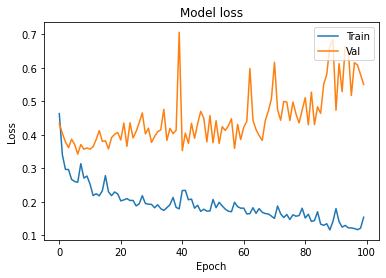

In [47]:
plt.plot(hist_2.history['loss'])
plt.plot(hist_2.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

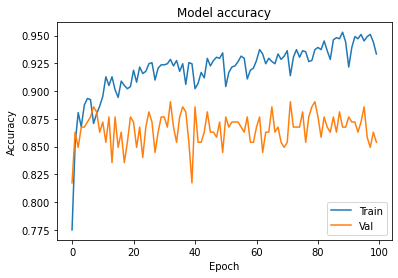

In [48]:
plt.plot(hist_2.history['accuracy'])
plt.plot(hist_2.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()